# Q5 — How should the target temperature be chosen?

Hypothesis: very small temperatures over-concentrate on noisy CV winners, very large temperatures approach prior averaging, and an intermediate value improves proper scores and calibration. Select temperature only inside training data in the final study.

In [1]:
from pathlib import Path
import sys
root = Path.cwd()
while root != root.parent and not (root / 'bayesian_predictive_model_averaging').is_dir():
    root = root.parent
sys.path.insert(0, str(root))
import matplotlib.pyplot as plt
from sklearn.metrics import log_loss
from EXPERIMENTS.common import classification_data, split_data, fit_classifier

In [2]:
X, y = classification_data(seed=19, kind='nonlinear')
X_train, X_test, y_train, y_test = split_data(X, y, seed=19)
temperatures = [0.1, 0.25, 0.5, 1.0, 2.0, 5.0]
results = []
for temperature in temperatures:
    model = fit_classifier(X_train, y_train, seed=19, temperature=temperature)
    results.append({
        'temperature': temperature,
        'log_loss': log_loss(y_test, model.predict_proba(X_test)),
        'ess_fraction': model.effective_sample_size_fraction_,
        'max_weight': max(draw.posterior_weight for draw in model._models),
    })
results

[{'temperature': 0.1,
  'log_loss': 0.32795805323669364,
  'ess_fraction': 0.8575360377774108,
  'max_weight': 0.21758735288078374},
 {'temperature': 0.25,
  'log_loss': 0.3337155972790108,
  'ess_fraction': 0.9718394133839037,
  'max_weight': 0.15935527060393614},
 {'temperature': 0.5,
  'log_loss': 0.3362690729057484,
  'ess_fraction': 0.9925970423924674,
  'max_weight': 0.1416614667624824},
 {'temperature': 1.0,
  'log_loss': 0.33765390081767743,
  'ess_fraction': 0.9981118239437426,
  'max_weight': 0.1331960277937469},
 {'temperature': 2.0,
  'log_loss': 0.33837180208214535,
  'ess_fraction': 0.9995238693494752,
  'max_weight': 0.12906368423915954},
 {'temperature': 5.0,
  'log_loss': 0.3388104146622743,
  'ess_fraction': 0.9999234595488564,
  'max_weight': 0.12661715488388967}]

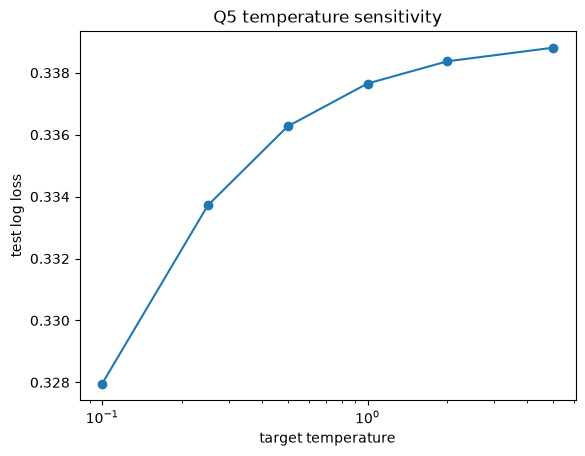

In [3]:
plt.plot([row['temperature'] for row in results], [row['log_loss'] for row in results], marker='o')
plt.xscale('log')
plt.xlabel('target temperature')
plt.ylabel('test log loss')
plt.title('Q5 temperature sensitivity')
plt.show()
# Repeat over outer splits; do not select the minimum using this test curve.


## Conclusion from the executed starter run

**Status: not falsified; temperature sensitivity confirmed.** The smallest tested temperature, 0.1, gave the best test log loss (0.3280), while temperature 5 gave 0.3388. Concentration changed as expected: ESS fraction fell to 0.858 and the maximum weight rose to 0.218 at 0.1, versus ESS 0.9999 at 5. This run does not test CV overfitting or show that an intermediate temperature is optimal.